# Numerical Simulation Laboratory — Esercizio 07

In questo esercizio studio un sistema di particelle interagenti tramite potenziale Lennard-Jones in fase liquida, usando sia simulazioni **Monte Carlo NVT** sia simulazioni **Molecular Dynamics NVE**.

Le condizioni termodinamiche richieste sono:

$$
\rho^\star = 0.8,
\qquad
T^\star = 1.1,
\qquad
r_c^\star = 2.5.
$$

Per la dinamica molecolare è stato usato:

$$
dt^\star = 0.001.
$$

Per il Monte Carlo, il parametro `DELTA` rappresenta l'ampiezza della proposta di traslazione in ciascuna direzione. È stato regolato in modo da ottenere un'accettazione circa pari al $50\%$.

Il notebook è organizzato secondo le quattro parti della consegna:

- **07.1**: tail corrections per energia potenziale e pressione;
- **07.2**: equilibrazione, produzione di misure istantanee di $U/N$, autocorrelazione e scelta della dimensione dei blocchi;
- **07.3**: implementazione e misura della funzione di distribuzione radiale $g(r)$;
- **07.4**: confronto finale tra MC NVT e MD NVE per $U/N$, $P$ e $g(r)$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 12,
})

ROOT = Path("Ex_07")
OUTPUT = ROOT / "OUTPUT"

def read_block_file(path, columns):
    return pd.read_csv(
        path,
        comment="#",
        sep=r"\s+",
        header=None,
        names=columns,
    )

def read_observable(path, obs_name):
    return read_block_file(
        path,
        ["block", f"actual_{obs_name}", f"average_{obs_name}", f"error_{obs_name}"]
    )

def read_acceptance(path):
    return read_block_file(path, ["block", "acceptance"])

def read_gofr(path):
    return read_block_file(
        path,
        ["block", "r", "block_gofr", "gofr_average", "gofr_error"]
    )

def final_value(df, obs_name):
    row = df.iloc[-1]
    return row[f"average_{obs_name}"], row[f"error_{obs_name}"]


## Esercizio 07.1 — Tail corrections

La simulazione usa condizioni periodiche al contorno e il potenziale Lennard-Jones viene troncato a $r_c$. Il potenziale ridotto è:

$$
V(r) = 4\left[\frac{1}{r^{12}} - \frac{1}{r^6}\right].
$$

Il troncamento rende il calcolo molto più efficiente, perché le interazioni tra particelle più lontane di $r_c$ non vengono calcolate esplicitamente. Tuttavia il potenziale Lennard-Jones ha una coda attrattiva proporzionale a $-1/r^6$, quindi le coppie con $r>r_c$ danno ancora un piccolo contributo medio all'energia e alla pressione.

Per stimare questo contributo si introducono le **tail corrections**. L'assunzione fisica è che, oltre il raggio di cut-off, il fluido sia praticamente omogeneo e non presenti più struttura locale significativa. In termini della funzione di distribuzione radiale, si assume quindi:

$$
g(r)\simeq 1 \qquad \text{per } r>r_c.
$$

Questa approssimazione significa che, a grandi distanze, la probabilità di trovare una particella in un guscio sferico è la stessa che si avrebbe in un gas uniforme con densità $\rho$. In questo modo non si conoscono le posizioni effettive delle particelle oltre $r_c$, ma si può stimare il loro contributo medio integrando analiticamente la coda del potenziale.

La correzione di coda per l'energia potenziale per particella è:

$$
\frac{U_\mathrm{tail}}{N}
=
8\pi\rho
\left[
\frac{1}{9r_c^9}
-
\frac{1}{3r_c^3}
\right].
$$

Il termine dominante è quello attrattivo, proporzionale a $-1/r_c^3$, quindi questa correzione rende l'energia potenziale più negativa. Fisicamente, stiamo aggiungendo il contributo medio delle interazioni attrattive a lungo raggio che il cut-off aveva escluso.

La correzione di coda per la pressione è:

$$
P_\mathrm{tail}
=
32\pi\rho^2
\left[
\frac{1}{9r_c^9}
-
\frac{1}{6r_c^3}
\right].
$$

In questo caso compare $\rho^2$ perché la pressione di interazione è legata al viriale, quindi al numero di coppie di particelle per unità di volume. Nel codice, però, la variabile `_ptail` contiene un solo fattore $\rho$:

```cpp
_ptail = 32.0 * M_PI * _rho *
         (1.0/(9.0*pow(_r_cut,9)) - 1.0/(6.0*pow(_r_cut,3)));
```

Il secondo fattore $\rho$ viene introdotto quando la pressione viene calcolata dividendo per il volume:

```cpp
_measurement(_index_pressure) =
    ideal_pressure + (_ptail*_npart + 48.0*virial/3.0)/_volume;
```

Infatti:

$$
\frac{\_ptail\,N}{V}
=
\_ptail\,\rho.
$$

Quindi il contributo finale alla pressione contiene effettivamente $\rho^2$, come nella formula analitica.


### Implementazione C++

Nel file `system.cpp` sono state aggiunte le correzioni:

```cpp
_vtail = 8.0 * M_PI * _rho *
         (1.0/(9.0*pow(_r_cut,9)) - 1.0/(3.0*pow(_r_cut,3)));

_ptail = 32.0 * M_PI * _rho *
         (1.0/(9.0*pow(_r_cut,9)) - 1.0/(6.0*pow(_r_cut,3)));
```

La pressione viene poi misurata come:

```cpp
_measurement(_index_pressure) =
    ideal_pressure + (_ptail*_npart + 48.0*virial/3.0)/_volume;
```

In questo modo il termine di coda effettivamente aggiunto alla pressione è proporzionale a $\rho^2$, come richiesto dalla formula analitica.


## Esercizio 07.2 — Equilibrazione e misure istantanee di $U/N$

La consegna richiede di produrre $M=5\times 10^5$ valori istantanei di energia potenziale per particella $U/N$ lungo simulazioni **già equilibrate**:

- MC NVT;
- MD NVE.

Per questo ho separato le simulazioni in due fasi:

1. equilibrazione;
2. produzione tramite restart.

Nelle run istantanee ho usato:

$$
N_\mathrm{blocks} = 500000,
\qquad
N_\mathrm{steps} = 1.
$$

In questo modo ogni blocco contiene una singola misura. La colonna `ACTUAL_PE` del file `potential_energy.dat` è quindi la serie istantanea di $U/N$.


### Tuning della temperatura iniziale MD

In MD NVE la temperatura non è imposta da un termostato: l'energia totale è fissata e la temperatura è legata all'energia cinetica media.

Partendo da una configurazione cristallina FCC perfetta, la temperatura cinetica non resta uguale alla temperatura usata per inizializzare le velocità. Per ottenere una temperatura equilibrata vicina a $T^\star=1.1$, è stato quindi necessario usare una temperatura iniziale più alta.

Per ogni temperatura iniziale ho considerato la media della temperatura sugli ultimi 2000 step della run di tuning, cioè sulla parte finale della traiettoria, dopo il transiente iniziale.

Il valore scelto è:

$$
T_\mathrm{input} = 1.986.
$$

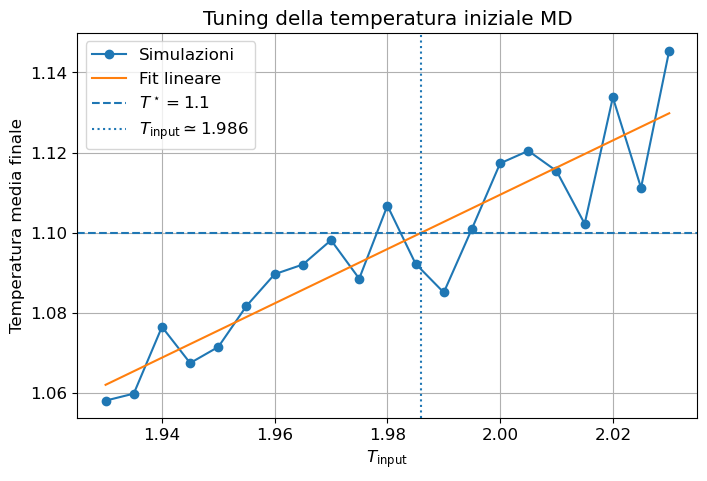

Fit lineare: T_finale = 0.6771 T_input + -0.2447
Temperatura iniziale stimata per ottenere T = 1.1: T_input ≈ 1.9860


In [2]:
# Cartella che contiene le simulazioni di tuning della temperatura iniziale.
temp_tuning_dir = OUTPUT / "temp_tuning"

# Lista in cui salvo una riga per ogni temperatura iniziale testata.
rows = []

# Scorro tutte le cartelle del tipo T1_94, T1_95, ...
for folder in sorted(temp_tuning_dir.glob("T*")):

    # File prodotto dalla run, contenente l'andamento della temperatura.
    temp_file = folder / "temperature.dat"

    # Ricavo il valore numerico della temperatura iniziale dal nome della cartella.
    # Esempio:
    # "T1_935" -> "1_935" -> "1.935" -> 1.935
    T_input = float(folder.name.replace("T", "").replace("_", "."))

    # Leggo il file della temperatura.
    temp = read_observable(temp_file, "T")

    # Stimo la temperatura finale come media degli ultimi 2000 valori.
    # In questo modo considero la parte finale della traiettoria,
    # dopo il rilassamento iniziale.
    rows.append({
        "T_input": T_input,
        "T_last_2000": temp["actual_T"].tail(2000).mean(),
    })

# Converto la lista in un DataFrame e ordino i punti in funzione di T_input.
temp_scan = pd.DataFrame(rows).sort_values("T_input")


# ============================================================
# Fit lineare
# ============================================================

# Temperatura target che voglio ottenere dopo il rilassamento.
T_target = 1.1

# Su un intervallo ristretto di temperature iniziali, la relazione tra
# temperatura iniziale e temperatura media finale è ben approssimata
# da una retta:
#
# T_finale = m T_input + q
m, q = np.polyfit(
    temp_scan["T_input"],
    temp_scan["T_last_2000"],
    1
)

# Uso la retta di fit per stimare quale temperatura iniziale produce
# una temperatura finale pari al valore target:
#
# T_target = m T_input_star + q
T_input_star = (T_target - q) / m

# Griglia fine di temperature iniziali usata solo per disegnare
# la retta di fit in modo continuo.
T_fit = np.linspace(
    temp_scan["T_input"].min(),
    temp_scan["T_input"].max(),
    200
)

# Valori previsti dalla retta di fit.
T_final_fit = m * T_fit + q


# ============================================================
# Grafico
# ============================================================

fig, ax = plt.subplots()

# Dati simulati. I punti sono collegati per evidenziare l'andamento
# della temperatura finale al variare della temperatura iniziale.
ax.plot(
    temp_scan["T_input"],
    temp_scan["T_last_2000"],
    marker="o",
    label="Simulazioni"
)

# Retta di fit lineare.
ax.plot(
    T_fit,
    T_final_fit,
    label="Fit lineare"
)

# Temperatura target desiderata.
ax.axhline(
    T_target,
    linestyle="--",
    label=rf"$T^\star={T_target}$"
)

# Temperatura iniziale stimata dal fit.
ax.axvline(
    T_input_star,
    linestyle=":",
    label=rf"$T_\mathrm{{input}}\simeq {T_input_star:.3f}$"
)

ax.set_xlabel(r"$T_\mathrm{input}$")
ax.set_ylabel("Temperatura media finale")
ax.set_title("Tuning della temperatura iniziale MD")
ax.legend()

plt.show()

print(f"Fit lineare: T_finale = {m:.4f} T_input + {q:.4f}")
print(f"Temperatura iniziale stimata per ottenere T = {T_target}: T_input ≈ {T_input_star:.4f}")


Dal tuning si osserva che la temperatura media finale cresce, in media, all'aumentare della temperatura iniziale impostata. Il fit lineare fornisce una stima di $T_\mathrm{input}\simeq 1.986$ per ottenere una temperatura finale vicina al valore target $T^\star=1.1$. Questo valore è quindi stato usato per la run di equilibrazione MD.


### Equilibrazione MD

La run di equilibrazione MD parte da configurazione FCC e genera velocità Maxwelliane a temperatura iniziale $T_\mathrm{input}=1.986$.

Parametri principali:

```text
SIMULATION_TYPE 0
RESTART 0
CONFIG_MODE FCC
TEMP 1.986
NPART 108
RHO 0.8
R_CUT 2.5
DELTA 0.001
NBLOCKS 5000
NSTEPS 1
```

Il numero totale di passi di equilibrazione è quindi:

$$
5000 \times 1 = 5000.
$$

Alla fine della run vengono salvati `config.xyz` e `conf-1.xyz`, entrambi necessari per il restart della dinamica Verlet.


In [3]:
md_eq_dir = OUTPUT / "liquid_MD_equilibration"

md_eq_T = read_observable(md_eq_dir / "temperature.dat", "T")
md_eq_PE = read_observable(md_eq_dir / "potential_energy.dat", "PE")
md_eq_TE = read_observable(md_eq_dir / "total_energy.dat", "TE")

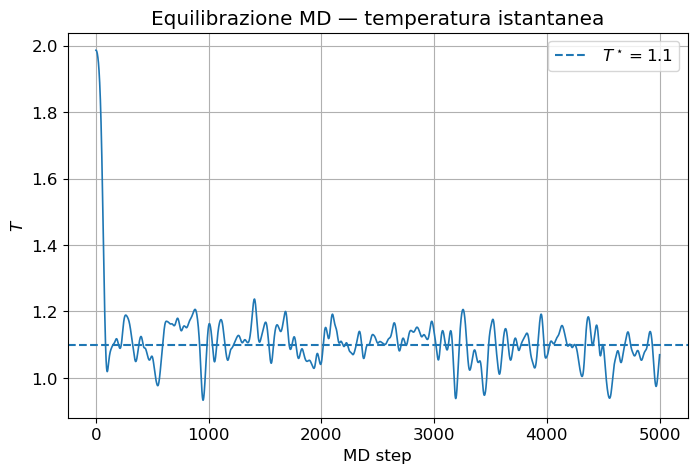

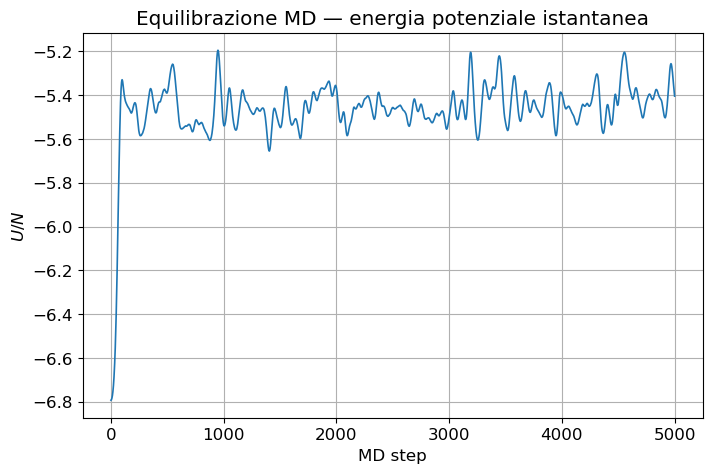

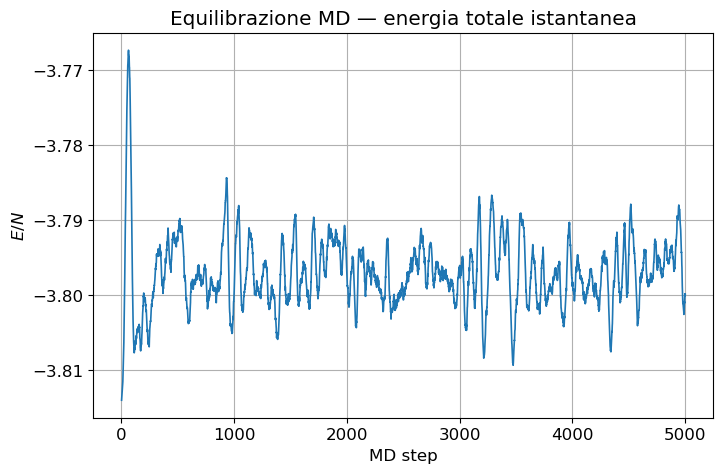

In [4]:
fig, ax = plt.subplots()
ax.plot(md_eq_T["block"], md_eq_T["actual_T"], lw=1.2)
ax.axhline(1.1, linestyle="--", label=r"$T^\star=1.1$")
ax.set_xlabel("MD step")
ax.set_ylabel(r"$T$")
ax.set_title("Equilibrazione MD — temperatura istantanea")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(md_eq_PE["block"], md_eq_PE["actual_PE"], lw=1.2)
ax.set_xlabel("MD step")
ax.set_ylabel(r"$U/N$")
ax.set_title("Equilibrazione MD — energia potenziale istantanea")
plt.show()

fig, ax = plt.subplots()
ax.plot(md_eq_TE["block"], md_eq_TE["actual_TE"], lw=1.2)
ax.set_xlabel("MD step")
ax.set_ylabel(r"$E/N$")
ax.set_title("Equilibrazione MD — energia totale istantanea")
plt.show()

La temperatura si stabilizza attorno al valore target $T^\star=1.1$. L'energia totale resta sostanzialmente costante, come atteso per una simulazione NVE.


### Equilibrazione MC

La run di equilibrazione MC parte dalla configurazione FCC. In questo caso la temperatura è imposta direttamente dall'ensemble canonico tramite $\beta=1/T$.

Parametri principali:

```text
SIMULATION_TYPE 1
RESTART 0
CONFIG_MODE FCC
TEMP 1.1
DELTA 0.1
NPART 108
RHO 0.8
R_CUT 2.5
NBLOCKS 5000
NSTEPS 1
```

Il parametro `DELTA=0.1` è stato scelto in modo da ottenere un'accettazione vicina al $50\%$.


In [5]:
mc_eq_dir = OUTPUT / "liquid_MC_equilibration"

mc_eq_PE = read_observable(mc_eq_dir / "potential_energy.dat", "PE")
mc_eq_P = read_observable(mc_eq_dir / "pressure.dat", "P")
mc_acc = read_acceptance(mc_eq_dir / "acceptance.dat")

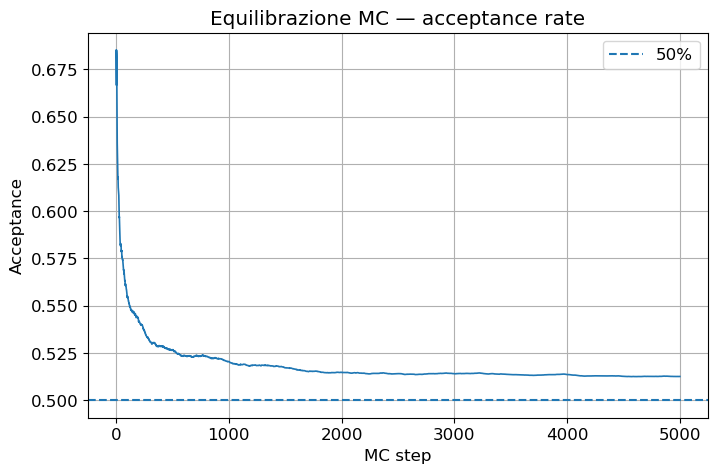

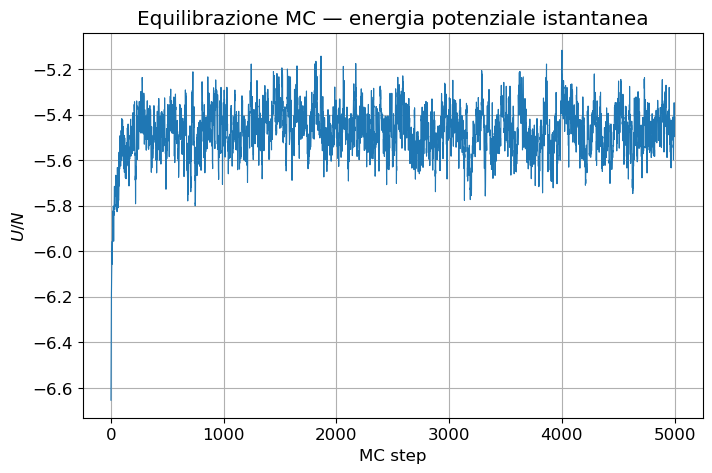

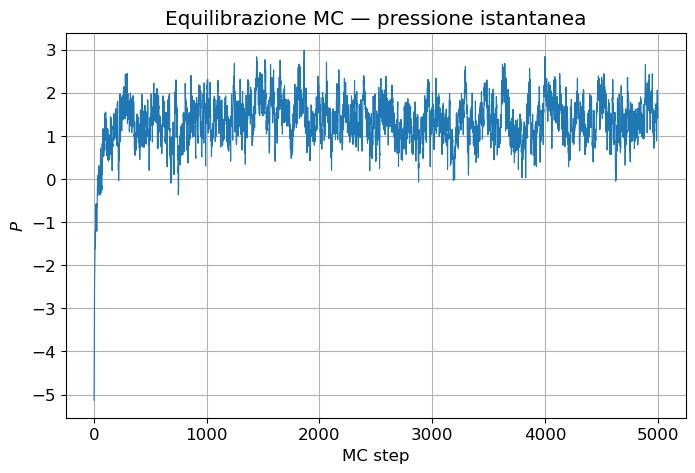

In [6]:
fig, ax = plt.subplots()
ax.plot(mc_acc["block"], mc_acc["acceptance"], lw=1.2)
ax.axhline(0.5, linestyle="--", label="50%")
ax.set_xlabel("MC step")
ax.set_ylabel("Acceptance")
ax.set_title("Equilibrazione MC — acceptance rate")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(mc_eq_PE["block"], mc_eq_PE["actual_PE"], lw=0.8)
ax.set_xlabel("MC step")
ax.set_ylabel(r"$U/N$")
ax.set_title("Equilibrazione MC — energia potenziale istantanea")
plt.show()

fig, ax = plt.subplots()
ax.plot(mc_eq_P["block"], mc_eq_P["actual_P"], lw=0.8)
ax.set_xlabel("MC step")
ax.set_ylabel(r"$P$")
ax.set_title("Equilibrazione MC — pressione istantanea")
plt.show()

L'accettazione si mantiene vicina al $50\%$, quindi il passo Metropolis scelto è adeguato.


### Run istantanee tramite restart

Dopo l'equilibrazione sono state eseguite due run di produzione con blocchi da una sola misura.

Parametri principali MD:

```text
SIMULATION_TYPE 0
RESTART 1
CONFIG_MODE STANDARD
TEMP 1.1
DELTA 0.001
NBLOCKS 500000
NSTEPS 1
PROPERTIES: POTENTIAL_ENERGY
```

Parametri principali MC:

```text
SIMULATION_TYPE 1
RESTART 1
CONFIG_MODE STANDARD
TEMP 1.1
DELTA 0.1
NBLOCKS 500000
NSTEPS 1
PROPERTIES: POTENTIAL_ENERGY
```

Per MD il restart usa `config.xyz` e `conf-1.xyz`. Per MC è sufficiente `config.xyz`.


In [7]:
md_inst = read_observable(OUTPUT / "liquid_MD_instant" / "potential_energy.dat", "PE")
mc_inst = read_observable(OUTPUT / "liquid_MC_instant" / "potential_energy.dat", "PE")

print("Numero misure MD:", len(md_inst))
print("Numero misure MC:", len(mc_inst))
print(f"Media MD U/N = {md_inst['actual_PE'].mean():.5f}")
print(f"Media MC U/N = {mc_inst['actual_PE'].mean():.5f}")

Numero misure MD: 500000
Numero misure MC: 500000
Media MD U/N = -5.45395
Media MC U/N = -5.46462


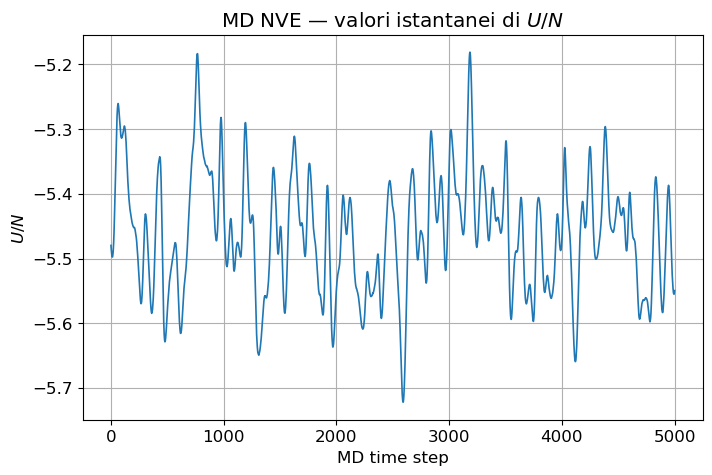

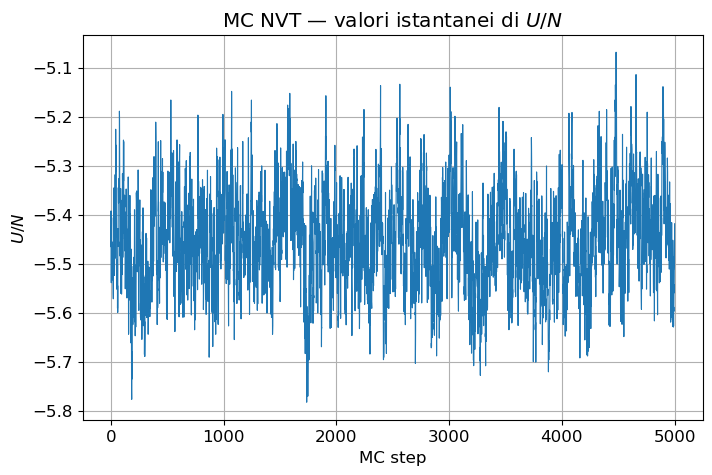

In [8]:
n_show = 5000

fig, ax = plt.subplots()
ax.plot(md_inst["block"].iloc[:n_show], md_inst["actual_PE"].iloc[:n_show], lw=1.2)
ax.set_xlabel("MD time step")
ax.set_ylabel(r"$U/N$")
ax.set_title("MD NVE — valori istantanei di $U/N$")
plt.show()

fig, ax = plt.subplots()
ax.plot(mc_inst["block"].iloc[:n_show], mc_inst["actual_PE"].iloc[:n_show], lw=0.8)
ax.set_xlabel("MC step")
ax.set_ylabel(r"$U/N$")
ax.set_title("MC NVT — valori istantanei di $U/N$")
plt.show()


Dai grafici delle misure istantanee si vede che le serie MD e MC oscillano attorno a valori medi simili di $U/N$, ma con dinamiche diverse. Le fluttuazioni non sono indipendenti punto per punto: valori consecutivi tendono a essere correlati, motivo per cui è necessario studiare l'autocorrelazione e scegliere blocchi sufficientemente lunghi nel data blocking.

Le due run istantanee contengono lo stesso numero di misure, cioè $5\times 10^5$. Non sono quindi stati prodotti più punti per MC rispetto a MD. Bisogna però ricordare che uno step MD e uno step MC non hanno lo stesso significato dinamico: in MD uno step è un passo di integrazione Verlet, mentre in MC uno step consiste in $N$ tentativi di spostamento di particelle scelte casualmente, cioè uno sweep in media. Per questo l'asse orizzontale permette di confrontare la lunghezza delle serie campionate, ma non rappresenta lo stesso tempo fisico nei due algoritmi.


### Autocorrelazione di $U/N$

La funzione di autocorrelazione normalizzata della serie $x_i=U_i/N$ è:

$$
C(t)
=
\frac{
\langle x_i x_{i+t} \rangle - \langle x_i \rangle^2
}{
\langle x_i^2 \rangle - \langle x_i \rangle^2
}.
$$

Il decadimento di $C(t)$ fornisce una stima della scala temporale su cui le misure successive restano correlate.


In [9]:
def autocorrelation(x, max_lag):

    x = np.asarray(x, dtype=float)

    # Numero totale di misure nella serie.
    n = len(x)

    # Non posso calcolare correlazioni per lag maggiori di n - 1.
    max_lag = min(max_lag, n - 1)

    # Media della serie.
    mean_x = np.mean(x)

    # Fluttuazioni rispetto alla media:
    #
    # delta_i = x_i - <x>
    delta = x - mean_x

    # Varianza della serie. La uso per normalizzare C(0) = 1.
    variance = np.mean(delta**2)

    # Array in cui salvo C(t) per t = 0, 1, ..., max_lag.
    acf = np.zeros(max_lag + 1)

    # Calcolo diretto della definizione discreta:
    #
    # C(t) = [1/(N-t) sum_i delta_i delta_{i+t}] / [1/N sum_i delta_i^2]
    for lag in range(max_lag + 1):

        # Confronto la serie con sé stessa traslata di lag passi.
        numerator = np.mean(delta[:n-lag] * delta[lag:])

        # Normalizzazione rispetto alla varianza.
        acf[lag] = numerator / variance

    return acf


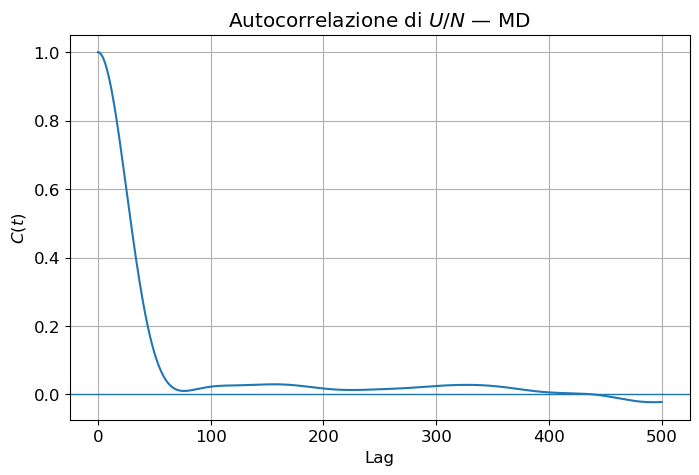

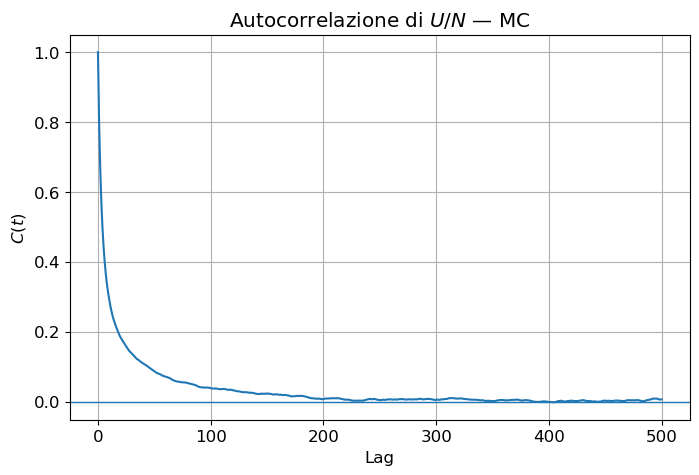

In [10]:
max_lag = 500

# Calcolo l'autocorrelazione di U/N per le due serie istantanee.
md_acf = autocorrelation(md_inst["actual_PE"].values, max_lag)
mc_acf = autocorrelation(mc_inst["actual_PE"].values, max_lag)

# Array dei lag temporali da rappresentare.
lags = np.arange(max_lag + 1)

fig, ax = plt.subplots()
ax.plot(lags, md_acf)
ax.axhline(0, lw=1)
ax.set_xlabel("Lag")
ax.set_ylabel(r"$C(t)$")
ax.set_title("Autocorrelazione di $U/N$ — MD")
plt.show()

fig, ax = plt.subplots()
ax.plot(lags, mc_acf)
ax.axhline(0, lw=1)
ax.set_xlabel("Lag")
ax.set_ylabel(r"$C(t)$")
ax.set_title("Autocorrelazione di $U/N$ — MC")
plt.show()


### Errore statistico con data blocking

Uso ora le stesse serie istantanee per studiare come cambia l'incertezza statistica al variare della dimensione del blocco $L$.

Se la serie contiene $M$ misure e ogni blocco contiene $L$ misure, il numero di blocchi è:

$$
N = \frac{M}{L}.
$$

Per ogni $L$ calcolo la media di ciascun blocco e l'errore sulla media globale:

$$
\sigma_{\langle x \rangle}
=
\frac{s_A}{\sqrt{N}},
$$

dove $s_A$ è la deviazione standard campionaria delle medie di blocco.

La consegna richiede di studiare $L$ da $10$ a $5000$.


In [11]:
def blocking_error(x, block_size):

    x = np.asarray(x, dtype=float)

    n_blocks = len(x) // block_size

    if n_blocks < 2:
        return np.nan, np.nan, n_blocks

    # Tengo solo i dati che entrano in blocchi completi.
    x_trimmed = x[:n_blocks * block_size]

    block_means = x_trimmed.reshape(n_blocks, block_size).mean(axis=1)

    mean = block_means.mean()
    error = block_means.std(ddof=1) / np.sqrt(n_blocks)

    return mean, error, n_blocks


def blocking_curve(x, block_sizes):
    # Costruisco una tabella con la stima dell'errore statistico
    # per diversi valori della lunghezza del blocco.
    rows = []

    # Scorro tutte le lunghezze di blocco che voglio testare.
    for L in block_sizes:

        # Calcolo media, errore e numero di blocchi usando blocchi di lunghezza L.
        mean, error, n_blocks = blocking_error(x, L)

        # Salvo i risultati in una riga della tabella.
        rows.append({
            "L": L,
            "N_blocks": n_blocks,
            "mean": mean,
            "error": error
        })
        
    return pd.DataFrame(rows)

L_values = np.arange(10, 5000 + 10, 10)

md_blocking = blocking_curve(md_inst["actual_PE"].values, L_values)

mc_blocking = blocking_curve(mc_inst["actual_PE"].values, L_values)

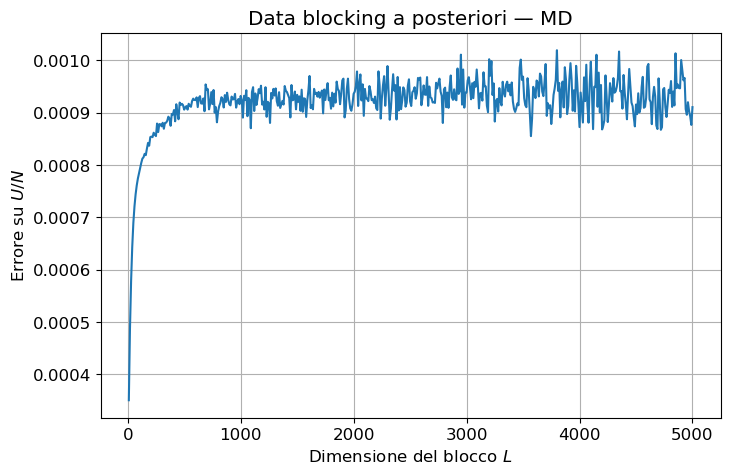

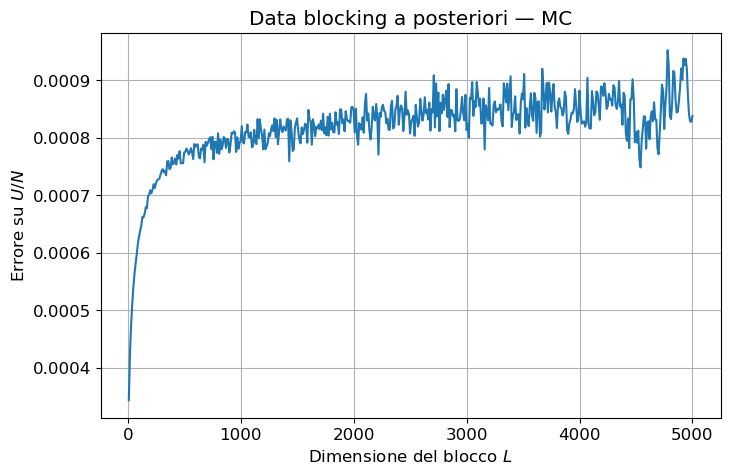

In [12]:
fig, ax = plt.subplots()
ax.plot(md_blocking["L"], md_blocking["error"])
ax.set_xlabel("Dimensione del blocco $L$")
ax.set_ylabel(r"Errore su $U/N$")
ax.set_title("Data blocking a posteriori — MD")
plt.show()

fig, ax = plt.subplots()
ax.plot(mc_blocking["L"], mc_blocking["error"])
ax.set_xlabel("Dimensione del blocco $L$")
ax.set_ylabel(r"Errore su $U/N$")
ax.set_title("Data blocking a posteriori — MC")
plt.show()

Per piccoli valori di $L$, le medie di blocco sono ancora correlate e l'errore può essere sottostimato. Quando $L$ diventa sufficientemente grande rispetto al tempo di autocorrelazione, l'errore tende a stabilizzarsi entro le fluttuazioni statistiche. Questa regione di plateau indica una scelta ragionevole per la lunghezza dei blocchi nelle run produttive.


## Esercizio 07.3 — Funzione di distribuzione radiale $g(r)$

La funzione di distribuzione radiale $g(r)$ misura la probabilità relativa di trovare una coppia di particelle a distanza $r$ rispetto a un gas ideale uniforme alla stessa densità.

Per un liquido Lennard-Jones ci si aspetta:

- $g(r)\simeq 0$ a distanze molto piccole, per la forte repulsione del potenziale;
- un primo picco marcato vicino alla distanza di primo vicino;
- oscillazioni successive dovute all'ordine locale del liquido;
- avvicinamento a $1$ per grandi distanze.

Nel codice, $g(r)$ viene calcolata per:

$$
r \in [0,L/2],
$$

dove $L$ è il lato della box.


### Implementazione C++

Nel ciclo sulle coppie $i<j$, se la distanza cade nel bin radiale corrispondente, il contributo viene normalizzato con il volume del guscio sferico:

$$
\Delta V
=
\frac{4\pi}{3}
\left[
r_{k+1}^3-r_k^3
\right].
$$

Poiché il ciclo conta le coppie non ordinate $i<j$, ma nella definizione di $g(r)$ si considerano le coppie ordinate, il contributo viene moltiplicato per $2$:

```cpp
_measurement(_index_gofr + bin) +=
    2.0 / (_rho * double(_npart) * shell_volume);
```

Alla fine di ogni blocco il codice scrive su `gofr.dat`:

```text
BLOCK  DISTANCE  BLOCK_GOFR  GOFR_AVE  ERROR
```

dove `GOFR_AVE` ed `ERROR` sono la media progressiva e la relativa incertezza.


## Esercizio 07.4 — Run produttive finali

Per confrontare MC NVT e MD NVE sono state eseguite due run produttive tramite restart dalle configurazioni equilibrate.

La scelta dei blocchi è:

$$
N_\mathrm{blocks} = 100,
\qquad
N_\mathrm{steps} = 5000.
$$

Il numero totale di passi resta:

$$
100 \times 5000 = 5\times 10^5.
$$

Le quantità misurate sono:

- energia potenziale per particella $U/N$;
- pressione $P$;
- funzione di distribuzione radiale $g(r)$.

Per MD sono state misurate anche temperatura ed energia totale, come controllo della simulazione NVE.


### Parametri delle run produttive

Parametri principali MD:

```text
SIMULATION_TYPE 0
RESTART 1
CONFIG_MODE STANDARD
TEMP 1.1
DELTA 0.001
NBLOCKS 100
NSTEPS 5000
PROPERTIES: POTENTIAL_ENERGY, KINETIC_ENERGY, TOTAL_ENERGY, TEMPERATURE, PRESSURE, GOFR 100
```

Parametri principali MC:

```text
SIMULATION_TYPE 1
RESTART 1
CONFIG_MODE STANDARD
TEMP 1.1
DELTA 0.1
NBLOCKS 100
NSTEPS 5000
PROPERTIES: POTENTIAL_ENERGY, PRESSURE, GOFR 100
```


In [13]:
md_prod_dir = OUTPUT / "liquid_MD_production"
mc_prod_dir = OUTPUT / "liquid_MC_production"

md_prod_PE = read_observable(md_prod_dir / "potential_energy.dat", "PE")
mc_prod_PE = read_observable(mc_prod_dir / "potential_energy.dat", "PE")

md_prod_P = read_observable(md_prod_dir / "pressure.dat", "P")
mc_prod_P = read_observable(mc_prod_dir / "pressure.dat", "P")

md_prod_T = read_observable(md_prod_dir / "temperature.dat", "T")
md_prod_TE = read_observable(md_prod_dir / "total_energy.dat", "TE")

md_gofr = read_gofr(md_prod_dir / "gofr.dat")
mc_gofr = read_gofr(mc_prod_dir / "gofr.dat")

md_U, md_U_err = final_value(md_prod_PE, "PE")
mc_U, mc_U_err = final_value(mc_prod_PE, "PE")

md_P, md_P_err = final_value(md_prod_P, "P")
mc_P, mc_P_err = final_value(mc_prod_P, "P")

md_T, md_T_err = final_value(md_prod_T, "T")
md_E, md_E_err = final_value(md_prod_TE, "TE")

print(f"MD: U/N = {md_U:.5f} ± {md_U_err:.5f}, P = {md_P:.5f} ± {md_P_err:.5f}")
print(f"MC: U/N = {mc_U:.5f} ± {mc_U_err:.5f}, P = {mc_P:.5f} ± {mc_P_err:.5f}")
print(f"Controllo MD: T = {md_T:.5f} ± {md_T_err:.5f}, E/N = {md_E:.5f} ± {md_E_err:.5f}")

MD: U/N = -5.45395 ± 0.00091, P = 1.44701 ± 0.00474
MC: U/N = -5.46462 ± 0.00083, P = 1.39576 ± 0.00438
Controllo MD: T = 1.09820 ± 0.00059, E/N = -3.80665 ± 0.00005


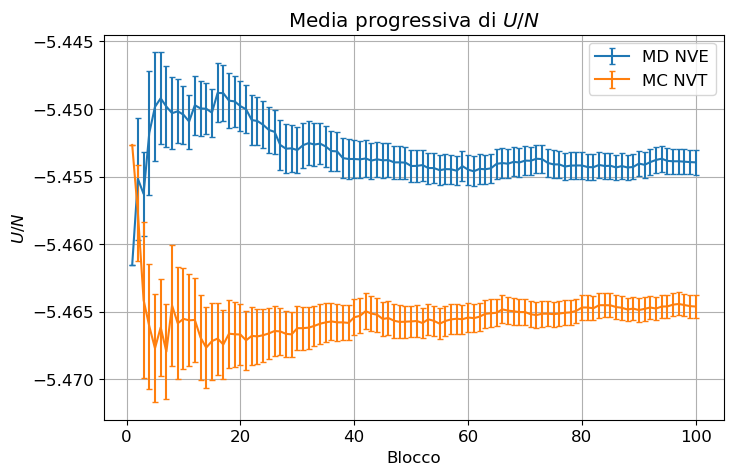

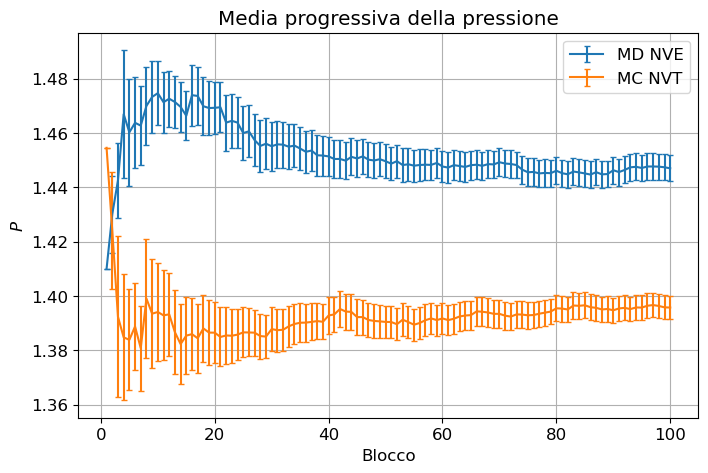

In [14]:
# Media progressiva di U/N: MD e MC nello stesso grafico

fig, ax = plt.subplots()

ax.errorbar(
    md_prod_PE["block"],
    md_prod_PE["average_PE"],
    yerr=md_prod_PE["error_PE"],
    capsize=2,
    label="MD NVE",
)

ax.errorbar(
    mc_prod_PE["block"],
    mc_prod_PE["average_PE"],
    yerr=mc_prod_PE["error_PE"],
    capsize=2,
    label="MC NVT",
)

ax.set_xlabel("Blocco")
ax.set_ylabel(r"$U/N$")
ax.set_title(r"Media progressiva di $U/N$")
ax.legend()
plt.show()


# Media progressiva della pressione: MD e MC nello stesso grafico

fig, ax = plt.subplots()

ax.errorbar(
    md_prod_P["block"],
    md_prod_P["average_P"],
    yerr=md_prod_P["error_P"],
    capsize=2,
    label="MD NVE",
)

ax.errorbar(
    mc_prod_P["block"],
    mc_prod_P["average_P"],
    yerr=mc_prod_P["error_P"],
    capsize=2,
    label="MC NVT",
)

ax.set_xlabel("Blocco")
ax.set_ylabel(r"$P$")
ax.set_title(r"Media progressiva della pressione")
ax.legend()
plt.show()

Le stime di $U/N$ ottenute con MC e MD sono vicine e descrivono circa lo stesso stato liquido. Tuttavia, entro le barre d’errore riportate, i valori non risultano sempre statisticamente compatibili. Questo non è necessariamente un problema: le due simulazioni non sono state effettuate esattamente alla stessa temperatura media effettiva. Poiché l’energia interna dipende da $T$, anche una piccola differenza nella temperatura di equilibrio può produrre uno scarto sistematico visibile quando le incertezze statistiche sono piccole. Nel complesso il confronto rimane qualitativamente coerente: i due metodi producono energie simili e, come si vede sotto, anche funzioni $g(r)$ confrontabili.


### Funzione di distribuzione radiale finale

Per ottenere la stima finale di $g(r)$ seleziono dal file `gofr.dat` solo le righe dell'ultimo blocco, cioè `BLOCK = 100`. In queste righe `GOFR_AVE` è la media progressiva finale e `ERROR` è l'incertezza statistica stimata tramite data blocking.


In [15]:
last_md_block = md_gofr["block"].max()
last_mc_block = mc_gofr["block"].max()

md_gofr_final = md_gofr[md_gofr["block"] == last_md_block].copy()
mc_gofr_final = mc_gofr[mc_gofr["block"] == last_mc_block].copy()

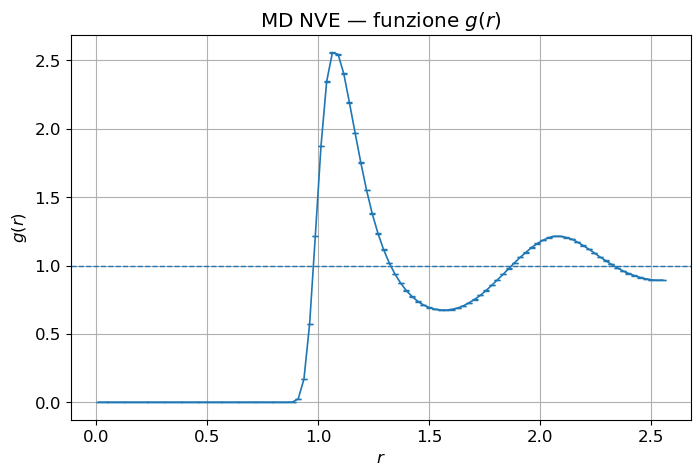

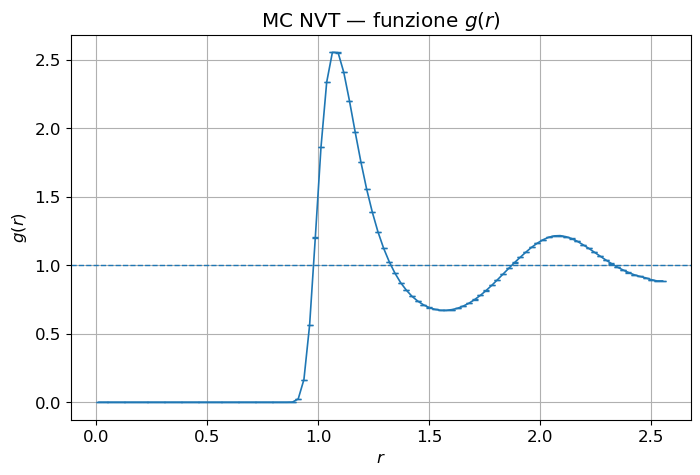

In [16]:
fig, ax = plt.subplots()
ax.errorbar(
    md_gofr_final["r"],
    md_gofr_final["gofr_average"],
    yerr=md_gofr_final["gofr_error"],
    capsize=2,
    lw=1.2,
)
ax.axhline(1.0, linestyle="--", lw=1)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$g(r)$")
ax.set_title(r"MD NVE — funzione $g(r)$")
plt.show()

fig, ax = plt.subplots()
ax.errorbar(
    mc_gofr_final["r"],
    mc_gofr_final["gofr_average"],
    yerr=mc_gofr_final["gofr_error"],
    capsize=2,
    lw=1.2,
)
ax.axhline(1.0, linestyle="--", lw=1)
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$g(r)$")
ax.set_title(r"MC NVT — funzione $g(r)$")
plt.show()

La funzione $g(r)$ mostra il comportamento atteso per un liquido Lennard-Jones: a piccole distanze è nulla a causa della repulsione del potenziale, poi compare un primo picco corrispondente alla shell dei primi vicini, seguito da oscillazioni smorzate. A grandi distanze $g(r)$ tende verso $1$, come atteso per un sistema che perde correlazione spaziale su scale lunghe.

Le curve ottenute con MC NVT e MD NVE sono confrontabili: questo indica che, dopo equilibrazione e restart, i due metodi campionano configurazioni compatibili per il liquido nelle condizioni termodinamiche richieste.


## Conclusioni

Nel caso MD NVE, la temperatura non è imposta durante la dinamica. Partendo da una configurazione FCC è stato quindi necessario scegliere una temperatura iniziale $T_\mathrm{input}=1.986$ per ottenere, dopo equilibrazione, una temperatura cinetica media vicina a $T^\star=1.1$.

Nel caso MC NVT, il parametro di passo $\Delta=0.1$ ha prodotto un'accettazione vicina al $50\%$, valore adeguato per un campionamento efficiente.

Le misure istantanee di $U/N$ hanno mostrato la presenza di autocorrelazione. Per questo motivo l'incertezza statistica deve essere stimata usando blocchi abbastanza grandi: l'errore cresce inizialmente con la dimensione del blocco e poi si stabilizza quando i blocchi diventano approssimativamente indipendenti.

Infine, le run produttive finali hanno permesso di confrontare MC e MD per $U/N$, pressione e $g(r)$. I risultati sono complessivamente coerenti e mostrano il comportamento fisico atteso per un liquido Lennard-Jones.
